# Square channel blockMeshDict generator by Sritej Kumbar(email-sritejtudarmstadt@gmail.com) under Jannis Reusch STFS for High-Re fully developed Turb. Channel Flow

Please cite Sritej, Jannis Reusch, Prof. Hasse when using this tool.

**Grading algorithm is based on: https://openfoamwiki.net/index.php/Scripts/blockMesh_grading_calculation**

**Standard for code generation IEEE 830 STD https://standards.ieee.org/ieee/830/1222/ due to stadardized Quality Code within department**

**Papers used for yPlus calcs reference** 

Dean(1978) R. B. Dean. “Reynolds Number Dependence of Skin Friction and Other Bulk Flow Variables in Two-Dimensional Rectangular Duct Flow”. In: Journal of Fluids Engineering 100.2 (June 1978), pp. 215–223. doi: 10.1115/1.3448633.

Afzal(2007) Noor Afzal, Abu Seena, and Afzal Bushra. “Power Law Velocity Profile in Fully Developed Turbulent Pipe and Channel Flows”. In: Journal of Hydraulic Engineering 133.9 (2007), pp. 1080–1090. doi: 10.1061/(ASCE)0733-9429(2007)133:9(1080).


**What User needs to do**
1. User provides flow inputs (`UBulk` ,`nu`) and geometry(`yPlus`).
2. The notebook estimates u_tau from empirical channel-flow relations.
3. it computes first cell-center distance, and optionally first cell thickness.
4. Using `wall_n_cells` and either `wall_cell_to_cell_ratio` or `wall_total_ratio`, it computes wall grading.
5. It converts the requested target core spacing into integer streamwise and core cell counts.
6. It writes a 9-block square-channel `blockMeshDict` and an `.rtf` copy.

**Parameters explained**
1. `length_x` (streamwise length, for below example `0.186m`), 
2. `outer_side`(`spanwise length = 0.062m` for below example), 
3. `blue_core_side` (`= 2* core_length`, here below diag. its `2*0.02578m`), 
4. `target_dx` (core cell size, here below diagram its `5e-4m`), 
5. `wall_n_cells`(`no.of cells at wall = 39`) 
6. `wall_total_ratio` or `cell-cell expansion ratio`(below example its `38.46` , this is also total exapansion ratio x ,y ,z values used in ` simpleGrading(x y z)`; while cell-cell expansion ratio is between two neighboring cell widths in a graded mesh with 1 means uniform mesh).

**Warning**
1. This tool assumes `high-Re` fully developed turbulent channel flow for the yPlus-based wall sizing. For other flows, verify u_tau independently.
2. Only one of `wall_cell_to_cell_ratio` or `wall_total_ratio` should be set.”
3. Check that the computed first cell thickness and wall block total thickness are physically consistent before running blockMesh.


**Workflow inside this notebook**
1. read the description
2. set the user inputs, in cell 7 , 
3. while test case is setup in cell 6 to verify whether mesh is generated. 
4. Preview is created with png name as `square_channel_cross_section_preview.png`
3. computes
4. writes `blockMeshDict`,  `.rtf`, `.json` and preview of mesh as outputs.




YPlus workflow:
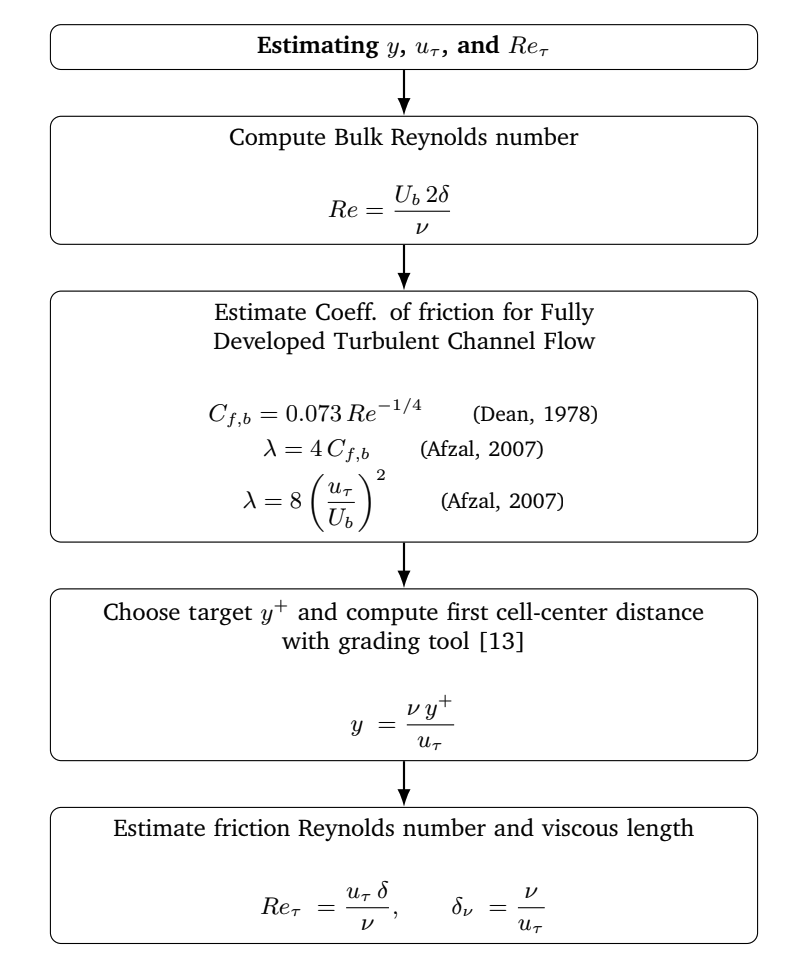

Idea of grid by me:
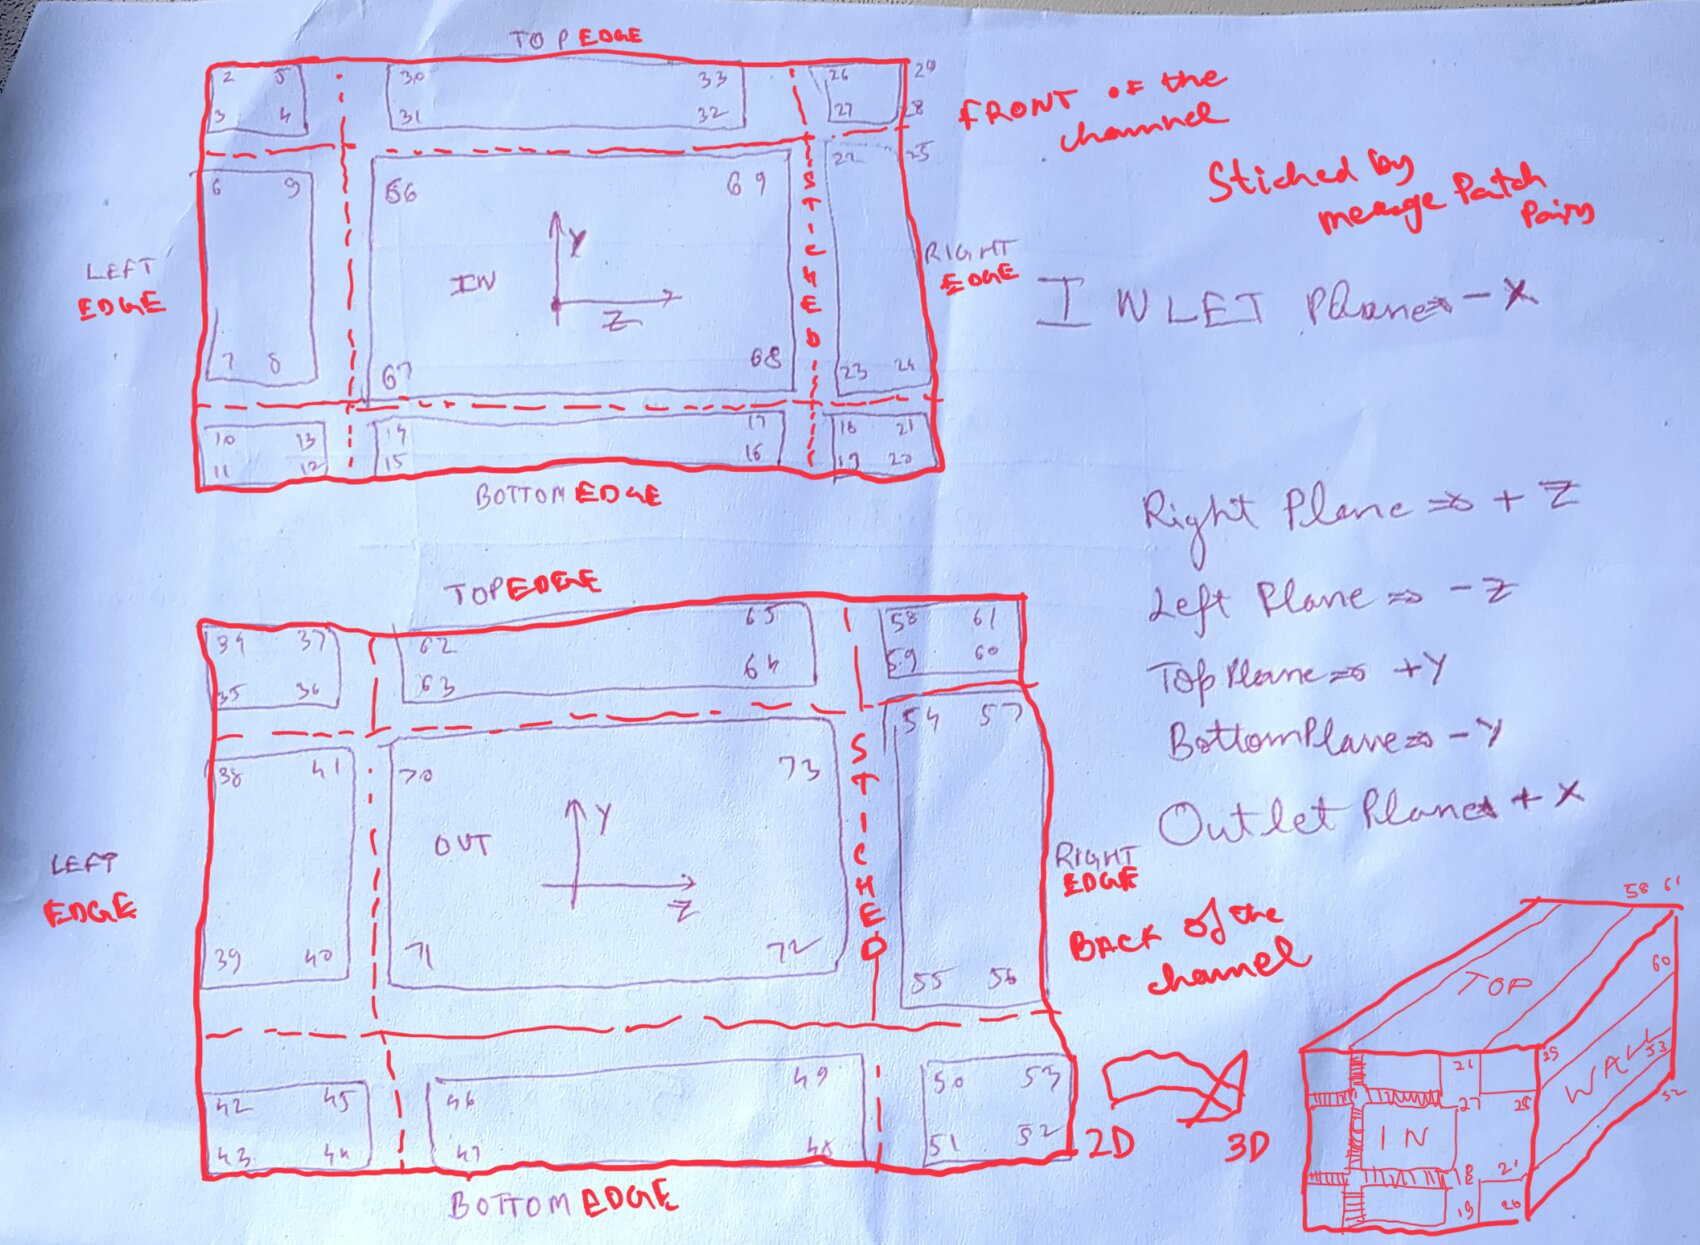

Preview:
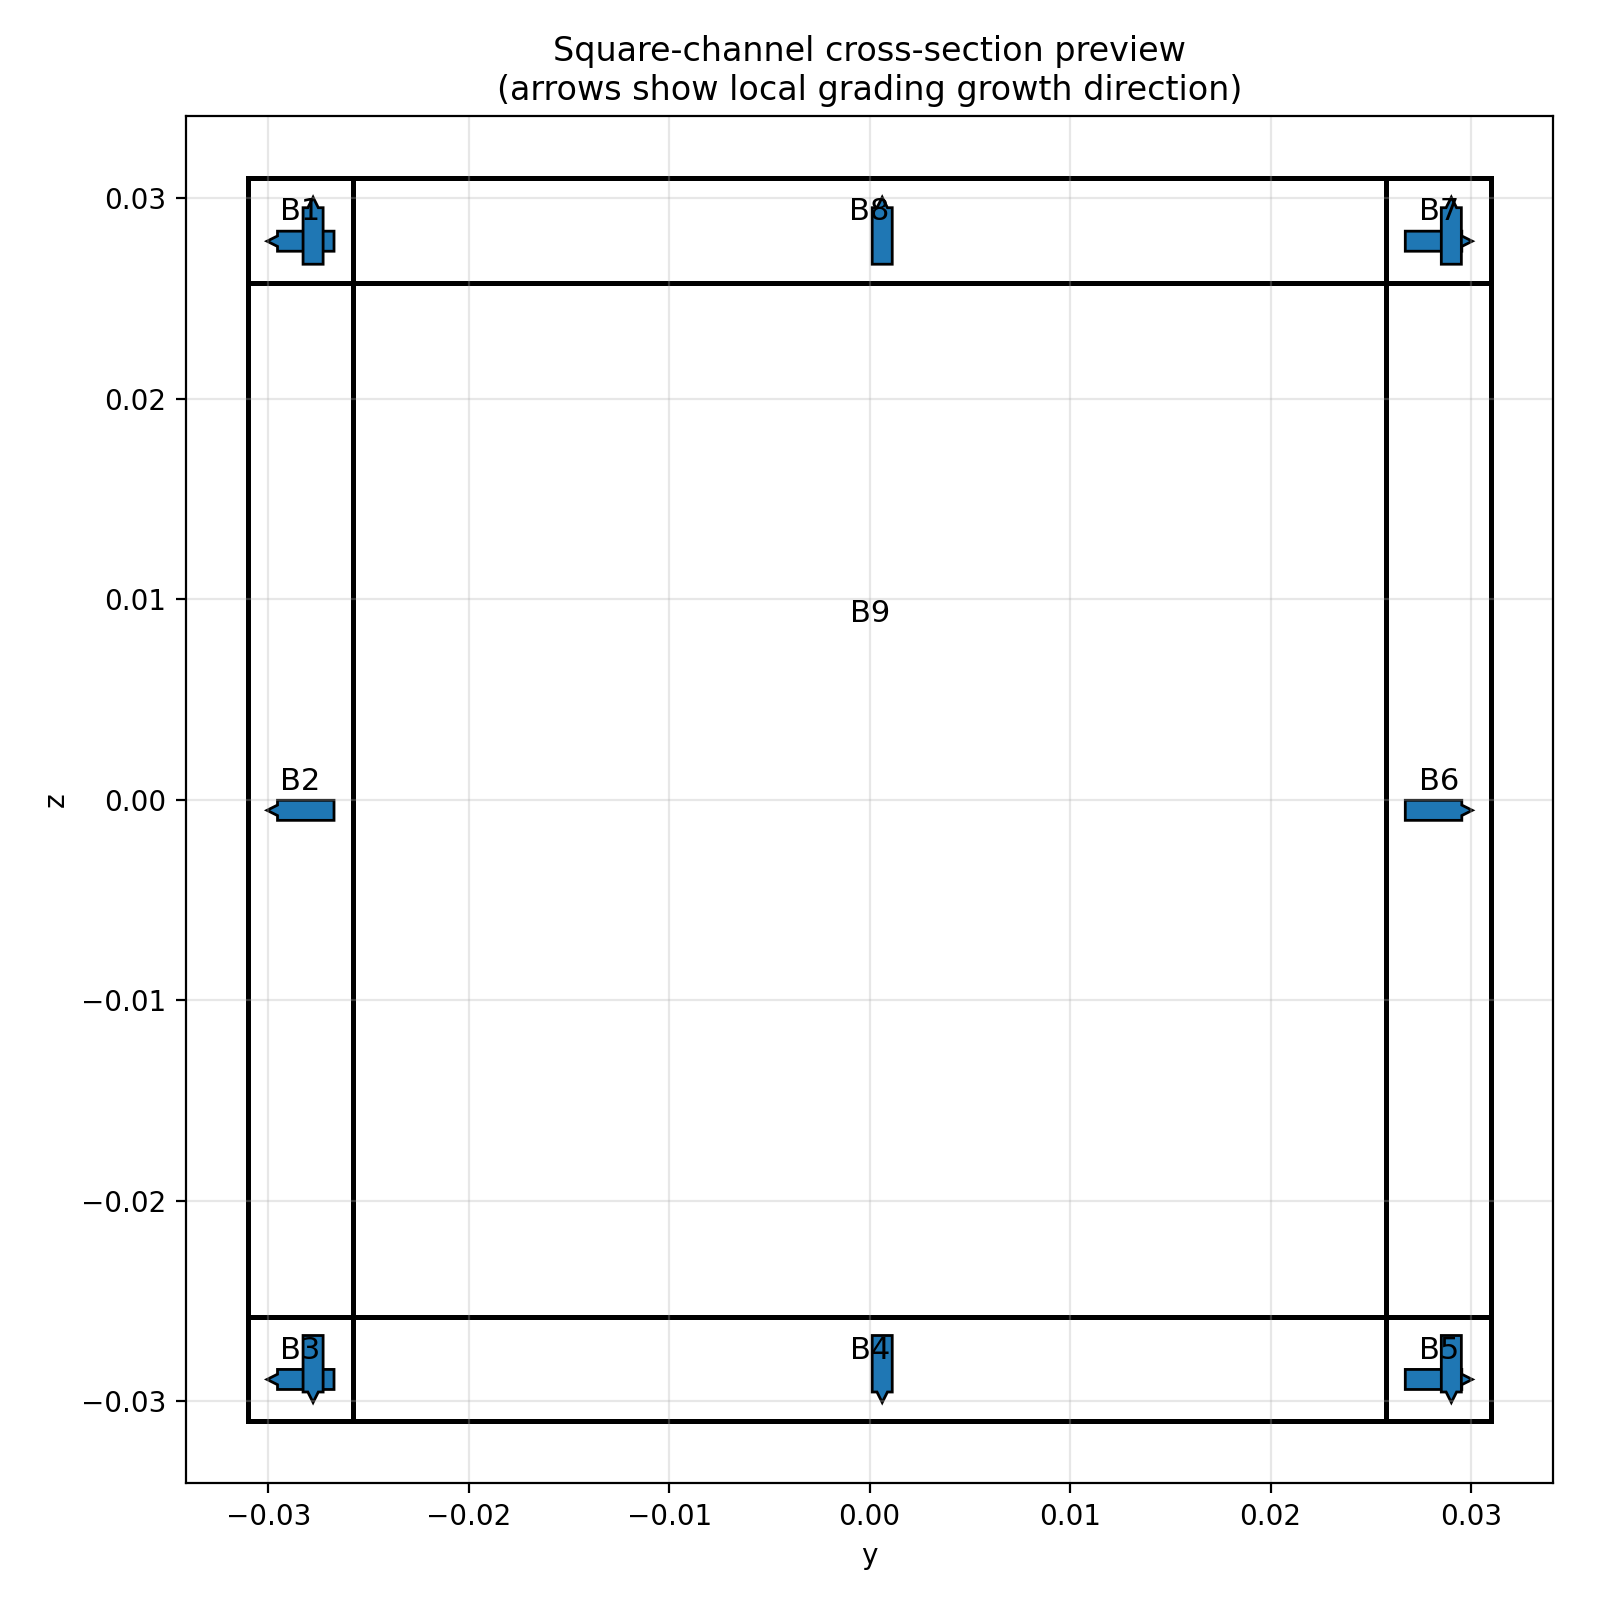


In [48]:
NOTE_FOR_USERS = """
Important assumptions and warnings:

1. The yPlus-based wall sizing uses empirical friction relations for fully developed turbulent channel flow.
   It may be inaccurate for transitional, separated, rough-wall, compressible, or developing flows.

2. Set only one of:
   - wall_total_ratio
   - wall_cell_to_cell_ratio

3. simpleGrading uses total end-to-start ratio along the local block direction, not the cell-to-cell ratio.

4. The first cell-center distance from the wall is not the same as the first full cell thickness.
   This code reports both.

5. Because this mesh uses duplicate interface patches and mergePatchPairs, manual edits to vertices,
   block ordering, face orientation, or merge pairs can break the mesh.
"""
print(NOTE_FOR_USERS)


Important assumptions and warnings:

1. The yPlus-based wall sizing uses empirical friction relations for fully developed turbulent channel flow.
   It may be inaccurate for transitional, separated, rough-wall, compressible, or developing flows.

2. Set only one of:
   - wall_total_ratio
   - wall_cell_to_cell_ratio

3. simpleGrading uses total end-to-start ratio along the local block direction, not the cell-to-cell ratio.

4. The first cell-center distance from the wall is not the same as the first full cell thickness.
   This code reports both.

5. Because this mesh uses duplicate interface patches and mergePatchPairs, manual edits to vertices,
   block ordering, face orientation, or merge pairs can break the mesh.



In [33]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import json
import logging
from typing import Callable, Dict, List, Tuple

import matplotlib.pyplot as plt


REL_TOL = 1.0e-12
ROOT_MAX_STEPS = 500
R_MAX = 1.0e5

DEFAULT_WALL_CELL_TO_CELL_RATIO = 1.1

LOGGER = logging.getLogger("square_channel_blockmesh")


# =============================================================================
# Logging
# =============================================================================

def configure_logging(level: int = logging.INFO) -> None:
    """Configure module logging once."""
    if not logging.getLogger().handlers:
        logging.basicConfig(
            level=level,
            format="%(levelname)s | %(name)s | %(message)s",
        )
    else:
        logging.getLogger().setLevel(level)


# =============================================================================
# Numerical helpers
# =============================================================================

def geometric_sum(width_a: float, c_ratio: float, n_cells: int) -> float:
    """Return sum of geometric progression of cell widths."""
    if n_cells < 1:
        return 0.0
    if abs(c_ratio - 1.0) < REL_TOL:
        return width_a * n_cells
    return width_a * (1.0 - c_ratio ** n_cells) / (1.0 - c_ratio)


def bulk_reynolds_number(U_bulk: float, channel_height: float, nu: float) -> float:
    """Compute bulk Reynolds number Re_b = U_bulk * H / nu."""
    if U_bulk <= 0.0 or channel_height <= 0.0 or nu <= 0.0:
        raise ValueError("U_bulk, channel_height and nu must be > 0")
    return U_bulk * channel_height / nu


def dean_cf_bulk(Re_b: float) -> float:
    """Dean correlation for bulk skin-friction coefficient."""
    if Re_b <= 0.0:
        raise ValueError("Re_b must be > 0")
    return 0.073 * Re_b ** (-0.25)


def darcy_lambda_from_cf_bulk(cf_bulk: float) -> float:
    """Convert bulk skin-friction coefficient to Darcy friction factor."""
    if cf_bulk <= 0.0:
        raise ValueError("cf_bulk must be > 0")
    return 4.0 * cf_bulk


def friction_velocity_from_bulk(U_bulk: float, darcy_lambda: float) -> float:
    """Estimate friction velocity from bulk velocity and Darcy friction factor."""
    if U_bulk <= 0.0 or darcy_lambda <= 0.0:
        raise ValueError("U_bulk and darcy_lambda must be > 0")
    return U_bulk * (darcy_lambda / 8.0) ** 0.5


def first_cell_center_from_yplus(y_plus: float, nu: float, u_tau: float) -> float:
    """Compute first cell-center distance from wall using y+ relation."""
    if y_plus <= 0.0 or nu <= 0.0 or u_tau <= 0.0:
        raise ValueError("y_plus, nu and u_tau must be > 0")
    return y_plus * nu / u_tau


def first_cell_thickness_from_center(y_center: float) -> float:
    """Convert first cell-center distance to first full cell thickness."""
    if y_center <= 0.0:
        raise ValueError("y_center must be > 0")
    return 2.0 * y_center


def total_ratio_from_cratio(n_cells: int, c_ratio: float) -> float:
    """Convert cell-to-cell ratio to total block ratio."""
    if n_cells <= 1:
        return 1.0
    return c_ratio ** (n_cells - 1)


def cratio_from_total_ratio(n_cells: int, total_ratio: float) -> float:
    """Convert total block ratio to cell-to-cell ratio."""
    if n_cells <= 1:
        return 1.0
    if total_ratio <= 0.0:
        raise ValueError("total_ratio must be > 0")
    return total_ratio ** (1.0 / (n_cells - 1))


def end_width_from_start_cratio_n(width_a: float, c_ratio: float, n_cells: int) -> float:
    """Compute final cell width from first width and cell-to-cell ratio."""
    return width_a * total_ratio_from_cratio(n_cells, c_ratio)


def bisect_root(
    func: Callable[[float], float],
    x1: float,
    x2: float,
    max_steps: int = ROOT_MAX_STEPS
) -> float:
    """Bisection root-finder."""
    f1 = func(x1)
    f2 = func(x2)

    if abs(f1) < REL_TOL:
        return x1
    if abs(f2) < REL_TOL:
        return x2
    if f1 * f2 > 0.0:
        raise ValueError(f"Root not bracketed: f({x1})={f1}, f({x2})={f2}")

    for _ in range(max_steps):
        xm = 0.5 * (x1 + x2)
        fm = func(xm)

        if abs(x2 - x1) < REL_TOL:
            return xm

        if f1 * fm < 0.0:
            x2 = xm
        else:
            x1 = xm
            f1 = fm

    return 0.5 * (x1 + x2)


def cratio_from_n_widthA_length(n_cells: int, width_a: float, length: float) -> float:
    """
    Solve c_ratio from:
        width_a + width_a*c + ... + width_a*c^(n-1) = length
    """
    if n_cells <= 0 or width_a <= 0.0 or length <= 0.0:
        raise ValueError("n_cells, width_a and length must be > 0")

    if n_cells == 1:
        return 1.0

    if abs(n_cells * width_a - length) / length < 1.0e-8:
        return 1.0

    def residual(c: float) -> float:
        return geometric_sum(width_a, c, n_cells) - length

    if n_cells * width_a < length:
        c_min = 1.0 + 1.0e-10
        c_max = R_MAX ** (1.0 / (n_cells - 1))
    else:
        c_min = (1.0 / R_MAX) ** (1.0 / (n_cells - 1))
        c_max = 1.0 - 1.0e-10

    return bisect_root(residual, c_min, c_max)


def n_cells_from_first_width_ratio_length(
    first_width: float,
    c_ratio: float,
    length: float,
    max_cells: int = 2000
) -> int:
    """
    Find integer number of cells whose geometric sum best matches target length.

    For c_ratio > 1, the sum grows with n and we stop once the target is crossed.
    For c_ratio == 1, n = round(length / first_width).
    For c_ratio < 1, we search all the way up to max_cells because the sum asymptotes.
    """
    if first_width <= 0.0 or c_ratio <= 0.0 or length <= 0.0:
        raise ValueError("first_width, c_ratio and length must be > 0")

    if abs(c_ratio - 1.0) < REL_TOL:
        n = max(1, int(round(length / first_width)))
        return n

    best_n = 1
    best_err = abs(geometric_sum(first_width, c_ratio, 1) - length)

    for n in range(2, max_cells + 1):
        total = geometric_sum(first_width, c_ratio, n)
        err = abs(total - length)

        if err < best_err:
            best_err = err
            best_n = n

        if c_ratio > 1.0 and total >= length:
            break

    return best_n


def n_cells_from_first_width_total_ratio_length(
    first_width: float,
    total_ratio: float,
    length: float,
    max_cells: int = 2000
) -> int:
    """
    Find integer number of cells when first width, total ratio and total length are given.
    For each candidate n, convert total_ratio -> cell_ratio and evaluate geometric sum.
    """
    if first_width <= 0.0 or total_ratio <= 0.0 or length <= 0.0:
        raise ValueError("first_width, total_ratio and length must be > 0")

    best_n = 1
    best_err = float("inf")

    for n in range(1, max_cells + 1):
        c = cratio_from_total_ratio(n, total_ratio)
        total = geometric_sum(first_width, c, n)
        err = abs(total - length)

        if err < best_err:
            best_err = err
            best_n = n

    return best_n


def rtf_escape(text: str) -> str:
    """Escape plain text for a minimal RTF file."""
    text = text.replace("\\", r"\\").replace("{", r"\{").replace("}", r"\}")
    return text.replace("\n", r"\par" + "\n")


def fmt(v: float) -> str:
    """Compact OpenFOAM-friendly float formatting."""
    return f"{v:.6f}" if abs(v) >= 1e-4 else f"{v:.7g}"


# =============================================================================
# Data models
# =============================================================================

@dataclass
class SquareChannelInputs:
    """User inputs for square-channel mesh generation."""
    length_x: float = 0.186
    outer_side: float = 0.062
    blue_core_side: float = 0.05156
    target_dx: float = 5.0e-4

    U_bulk: float = 20.0
    y_plus_wall: float = 0.7
    nu: float = 18.6e-6

    wall_n_cells: int | None = 39
    wall_cell_to_cell_ratio: float | None = None
    wall_total_ratio: float | None = 38.46

    output_folder: str = "./square_channel_outputs_corrected"
    block_mesh_filename: str = "blockMeshDict_squareChannel_corrected"
    rtf_filename: str = "blockMeshDict_squareChannel_corrected.rtf"
    json_filename: str = "square_channel_mesh_summary_corrected.json"
    preview_png_filename: str = "square_channel_cross_section_preview.png"


@dataclass
class SquareChannelMesh:
    """Derived mesh and flow quantities."""
    length_x: float
    outer_side: float
    blue_core_side: float
    outer_half: float
    blue_half: float
    wall_thickness: float
    channel_height: float
    target_dx: float
    nx: int
    n_core: int
    n_wall: int
    actual_dx_x: float
    actual_dx_core: float

    U_bulk: float
    nu: float
    y_plus_wall: float
    Re_bulk: float
    cf_bulk: float
    darcy_lambda: float
    u_tau: float

    first_wall_cell_center: float
    first_wall_cell_thickness: float

    wall_cell_to_cell_ratio: float
    wall_total_ratio: float
    wall_end_cell: float
    wall_total_thickness_check: float
    wall_mode: str


@dataclass
class ValidationReport:
    """Container for validation results."""
    errors: List[str]
    warnings: List[str]

    @property
    def ok(self) -> bool:
        return len(self.errors) == 0


# =============================================================================
# Mesh computation
# =============================================================================

def resolve_wall_grading(
    wall_thickness: float,
    first_thickness: float,
    wall_n_cells: int | None,
    wall_cell_to_cell_ratio: float | None,
    wall_total_ratio: float | None,
) -> Tuple[int, float, str, List[str]]:
    """
    Resolve wall grading mode cleanly.

    Returns:
        n_wall, wall_c, mode_string, warnings_list
    """
    warnings: List[str] = []

    all_none = (
        wall_n_cells is None and
        wall_cell_to_cell_ratio is None and
        wall_total_ratio is None
    )

    if all_none:
        warnings.append(
            f"wall_n_cells, wall_total_ratio and wall_cell_to_cell_ratio are all None. "
            f"Default selection is occurring: wall_cell_to_cell_ratio={DEFAULT_WALL_CELL_TO_CELL_RATIO}. "
            f"wall_n_cells remains None and will be calculated automatically from the y+ based first-cell thickness."
        )
        wall_cell_to_cell_ratio = DEFAULT_WALL_CELL_TO_CELL_RATIO

    if wall_n_cells is not None:
        if wall_n_cells < 1:
            raise ValueError("wall_n_cells must be >= 1")

        if wall_cell_to_cell_ratio is not None and wall_total_ratio is not None:
            raise ValueError(
                "Give only one of wall_cell_to_cell_ratio or wall_total_ratio when wall_n_cells is fixed"
            )

        if wall_total_ratio is not None:
            wall_c = cratio_from_total_ratio(wall_n_cells, wall_total_ratio)
            mode = "fixed_n__fixed_total_ratio"
        elif wall_cell_to_cell_ratio is not None:
            if wall_cell_to_cell_ratio <= 0.0:
                raise ValueError("wall_cell_to_cell_ratio must be > 0")
            wall_c = wall_cell_to_cell_ratio
            mode = "fixed_n__fixed_cell_ratio"
        else:
            wall_c = cratio_from_n_widthA_length(wall_n_cells, first_thickness, wall_thickness)
            mode = "fixed_n__solved_cell_ratio"

        return wall_n_cells, wall_c, mode, warnings

    # wall_n_cells is None here
    if wall_cell_to_cell_ratio is not None and wall_total_ratio is not None:
        raise ValueError(
            "If wall_n_cells is None, give only one of wall_cell_to_cell_ratio or wall_total_ratio"
        )

    if wall_cell_to_cell_ratio is not None:
        if wall_cell_to_cell_ratio <= 0.0:
            raise ValueError("wall_cell_to_cell_ratio must be > 0")
        n_wall = n_cells_from_first_width_ratio_length(
            first_thickness, wall_cell_to_cell_ratio, wall_thickness
        )
        wall_c = wall_cell_to_cell_ratio
        mode = "solved_n__fixed_cell_ratio"
        return n_wall, wall_c, mode, warnings

    if wall_total_ratio is not None:
        n_wall = n_cells_from_first_width_total_ratio_length(
            first_thickness, wall_total_ratio, wall_thickness
        )
        wall_c = cratio_from_total_ratio(n_wall, wall_total_ratio)
        mode = "solved_n__fixed_total_ratio"
        return n_wall, wall_c, mode, warnings

    raise ValueError("Internal error: wall grading mode could not be resolved")


def compute_square_channel_mesh(inp: SquareChannelInputs) -> SquareChannelMesh:
    """Compute derived mesh data from user inputs."""
    if inp.blue_core_side >= inp.outer_side:
        raise ValueError("blue_core_side must be smaller than outer_side")

    outer_half = 0.5 * inp.outer_side
    blue_half = 0.5 * inp.blue_core_side
    wall_thickness = outer_half - blue_half
    channel_height = inp.outer_side

    if wall_thickness <= 0.0:
        raise ValueError("wall thickness must be > 0")

    Re_bulk = bulk_reynolds_number(inp.U_bulk, channel_height, inp.nu)
    cf_bulk = dean_cf_bulk(Re_bulk)
    darcy_lambda = darcy_lambda_from_cf_bulk(cf_bulk)
    u_tau = friction_velocity_from_bulk(inp.U_bulk, darcy_lambda)

    first_center = first_cell_center_from_yplus(inp.y_plus_wall, inp.nu, u_tau)
    first_thickness = first_cell_thickness_from_center(first_center)

    n_wall, wall_c, wall_mode, mode_warnings = resolve_wall_grading(
        wall_thickness=wall_thickness,
        first_thickness=first_thickness,
        wall_n_cells=inp.wall_n_cells,
        wall_cell_to_cell_ratio=inp.wall_cell_to_cell_ratio,
        wall_total_ratio=inp.wall_total_ratio,
    )

    for msg in mode_warnings:
        LOGGER.warning(msg)

    wall_total = geometric_sum(first_thickness, wall_c, n_wall)
    wall_end = end_width_from_start_cratio_n(first_thickness, wall_c, n_wall)
    wall_total_ratio = wall_end / first_thickness

    nx = max(1, int(round(inp.length_x / inp.target_dx)))
    n_core = max(1, int(round(inp.blue_core_side / inp.target_dx)))

    LOGGER.info("Resolved wall grading mode: %s", wall_mode)
    

    return SquareChannelMesh(
        length_x=inp.length_x,
        outer_side=inp.outer_side,
        blue_core_side=inp.blue_core_side,
        outer_half=outer_half,
        blue_half=blue_half,
        wall_thickness=wall_thickness,
        channel_height=channel_height,
        target_dx=inp.target_dx,
        nx=nx,
        n_core=n_core,
        n_wall=n_wall,
        actual_dx_x=inp.length_x / nx,
        actual_dx_core=inp.blue_core_side / n_core,
        U_bulk=inp.U_bulk,
        nu=inp.nu,
        y_plus_wall=inp.y_plus_wall,
        Re_bulk=Re_bulk,
        cf_bulk=cf_bulk,
        darcy_lambda=darcy_lambda,
        u_tau=u_tau,
        first_wall_cell_center=first_center,
        first_wall_cell_thickness=first_thickness,
        wall_cell_to_cell_ratio=wall_c,
        wall_total_ratio=wall_total_ratio,
        wall_end_cell=wall_end,
        wall_total_thickness_check=wall_total,
        wall_mode=wall_mode,
    )


# =============================================================================
# blockMeshDict writer
# =============================================================================

def build_vertices(mesh: SquareChannelMesh) -> List[str]:
    """Build vertex list in the required duplicated-vertex topology."""
    x0 = 0.0
    x1 = mesh.length_x
    oh = mesh.outer_half
    bh = mesh.blue_half

    V = [
        (x0, 0.0, 0.0),
        (1e-7, 1e-7, 1e-7),

        (x0, +oh, -oh), (x0, +bh, -oh), (x0, +bh, -bh), (x0, +oh, -bh),
        (x0, +bh, -oh), (x0, -bh, -oh), (x0, -bh, -bh), (x0, +bh, -bh),
        (x0, -bh, -oh), (x0, -oh, -oh), (x0, -oh, -bh), (x0, -bh, -bh),
        (x0, -bh, -bh), (x0, -oh, -bh), (x0, -oh, +bh), (x0, -bh, +bh),
        (x0, -bh, +bh), (x0, -oh, +bh), (x0, -oh, +oh), (x0, -bh, +oh),
        (x0, +bh, +bh), (x0, -bh, +bh), (x0, -bh, +oh), (x0, +bh, +oh),
        (x0, +oh, +bh), (x0, +bh, +bh), (x0, +bh, +oh), (x0, +oh, +oh),
        (x0, +oh, -bh), (x0, +bh, -bh), (x0, +bh, +bh), (x0, +oh, +bh),

        (x1, +oh, -oh), (x1, +bh, -oh), (x1, +bh, -bh), (x1, +oh, -bh),
        (x1, +bh, -oh), (x1, -bh, -oh), (x1, -bh, -bh), (x1, +bh, -bh),
        (x1, -bh, -oh), (x1, -oh, -oh), (x1, -oh, -bh), (x1, -bh, -bh),
        (x1, -bh, -bh), (x1, -oh, -bh), (x1, -oh, +bh), (x1, -bh, +bh),
        (x1, -bh, +bh), (x1, -oh, +bh), (x1, -oh, +oh), (x1, -bh, +oh),
        (x1, +bh, +bh), (x1, -bh, +bh), (x1, -bh, +oh), (x1, +bh, +oh),
        (x1, +oh, +bh), (x1, +bh, +bh), (x1, +bh, +oh), (x1, +oh, +oh),
        (x1, +oh, -bh), (x1, +bh, -bh), (x1, +bh, +bh), (x1, +oh, +bh),

        (x0, +bh, -bh), (x0, -bh, -bh), (x0, -bh, +bh), (x0, +bh, +bh),
        (x1, +bh, -bh), (x1, -bh, -bh), (x1, -bh, +bh), (x1, +bh, +bh),
    ]

    return [f"    ({fmt(x)} {fmt(y)} {fmt(z)}) //{i}" for i, (x, y, z) in enumerate(V)]


def get_vertex_coords(mesh: SquareChannelMesh) -> List[Tuple[float, float, float]]:
    """Return raw vertex coordinates in the same index order as the blockMesh list."""
    x0 = 0.0
    x1 = mesh.length_x
    oh = mesh.outer_half
    bh = mesh.blue_half

    return [
        (x0, 0.0, 0.0),
        (1e-7, 1e-7, 1e-7),

        (x0, +oh, -oh), (x0, +bh, -oh), (x0, +bh, -bh), (x0, +oh, -bh),
        (x0, +bh, -oh), (x0, -bh, -oh), (x0, -bh, -bh), (x0, +bh, -bh),
        (x0, -bh, -oh), (x0, -oh, -oh), (x0, -oh, -bh), (x0, -bh, -bh),
        (x0, -bh, -bh), (x0, -oh, -bh), (x0, -oh, +bh), (x0, -bh, +bh),
        (x0, -bh, +bh), (x0, -oh, +bh), (x0, -oh, +oh), (x0, -bh, +oh),
        (x0, +bh, +bh), (x0, -bh, +bh), (x0, -bh, +oh), (x0, +bh, +oh),
        (x0, +oh, +bh), (x0, +bh, +bh), (x0, +bh, +oh), (x0, +oh, +oh),
        (x0, +oh, -bh), (x0, +bh, -bh), (x0, +bh, +bh), (x0, +oh, +bh),

        (x1, +oh, -oh), (x1, +bh, -oh), (x1, +bh, -bh), (x1, +oh, -bh),
        (x1, +bh, -oh), (x1, -bh, -oh), (x1, -bh, -bh), (x1, +bh, -bh),
        (x1, -bh, -oh), (x1, -oh, -oh), (x1, -oh, -bh), (x1, -bh, -bh),
        (x1, -bh, -bh), (x1, -oh, -bh), (x1, -oh, +bh), (x1, -bh, +bh),
        (x1, -bh, +bh), (x1, -oh, +bh), (x1, -oh, +oh), (x1, -bh, +oh),
        (x1, +bh, +bh), (x1, -bh, +bh), (x1, -bh, +oh), (x1, +bh, +oh),
        (x1, +oh, +bh), (x1, +bh, +bh), (x1, +bh, +oh), (x1, +oh, +oh),
        (x1, +oh, -bh), (x1, +bh, -bh), (x1, +bh, +bh), (x1, +oh, +bh),

        (x0, +bh, -bh), (x0, -bh, -bh), (x0, -bh, +bh), (x0, +bh, +bh),
        (x1, +bh, -bh), (x1, -bh, -bh), (x1, -bh, +bh), (x1, +bh, +bh),
    ]


def build_blocks(mesh: SquareChannelMesh) -> List[str]:
    """Build the 9 hex blocks with required grading directions."""
    nx = mesh.nx
    nw = mesh.n_wall
    nc = mesh.n_core

    r = mesh.wall_total_ratio
    rinv = 1.0 / r

    return [
        f"hex (5 37 36 4 2 34 35 3 ) ({nx} {nw} {nw}) simpleGrading (1 {fmt(r)} {fmt(rinv)})",
        f"hex (9 41 40 8 6 38 39 7) ({nx} {nc} {nw}) simpleGrading (1 1 {fmt(rinv)})",
        f"hex (29 61 60 28 26 58 59 27) ({nx} {nw} {nw}) simpleGrading (1 {fmt(r)} {fmt(r)})",
        f"hex (25 57 56 24 22 54 55 23) ({nx} {nc} {nw}) simpleGrading (1 1 {fmt(r)})",
        f"hex (13 45 44 12 10 42 43 11 ) ({nx} {nw} {nw}) simpleGrading (1 {fmt(rinv)} {fmt(rinv)})",
        f"hex (21 53 52 20 18 50 51 19 ) ({nx} {nw} {nw}) simpleGrading (1 {fmt(rinv)} {fmt(r)})",
        f"hex (17 49 48 16 14 46 47 15) ({nx} {nw} {nc}) simpleGrading (1 {fmt(rinv)} 1)",
        f"hex (33 65 64 32 30 62 63 31 ) ({nx} {nw} {nc}) simpleGrading (1 {fmt(r)} 1)",
        f"hex (69 73 72 68 66 70 71 67) ({nx} {nc} {nc}) simpleGrading (1 1 1)",
    ]


def get_block_vertex_lists() -> List[Tuple[int, ...]]:
    """Return block vertex tuples for topology checks and preview."""
    return [
        (5, 37, 36, 4, 2, 34, 35, 3),
        (9, 41, 40, 8, 6, 38, 39, 7),
        (29, 61, 60, 28, 26, 58, 59, 27),
        (25, 57, 56, 24, 22, 54, 55, 23),
        (13, 45, 44, 12, 10, 42, 43, 11),
        (21, 53, 52, 20, 18, 50, 51, 19),
        (17, 49, 48, 16, 14, 46, 47, 15),
        (33, 65, 64, 32, 30, 62, 63, 31),
        (69, 73, 72, 68, 66, 70, 71, 67),
    ]


def build_boundary_lines() -> List[str]:
    """Build fixed boundary and interface definitions."""
    return [
        "    bottom",
        "    {",
        "        type            wall;",
        "        faces           ((11 43 44 12)(15 47 48 16)(19 51 52 20));",
        "    }",
        "    top",
        "    {",
        "        type            wall;",
        "        faces           ((2 34 37 5)(30 62 65 33)(26 58 61 29));",
        "    }",
        "    left",
        "    {",
        "        type            wall;",
        "        neighbourPatch  right;",
        "        faces           ((2 3 35 34)(6 7 39 38) (10 11 43 42));",
        "    }",
        "    right",
        "    {",
        "        type            wall;",
        "        neighbourPatch  left;",
        "        faces           ((29 61 60 28)(25 57 56 24)(21 53 52 20));",
        "    }",
        "    inlet",
        "    {",
        "        type            cyclic;",
        "        neighbourPatch  outlet;",
        "        faces           ((2 3 4 5)(6 7 8 9)(10 11 12 13)(14 15 16 17)(18 19 20 21)(22 23 24 25)(26 27 28 29)(30 31 32 33)(66 67 68 69));",
        "    }",
        "    outlet",
        "    {",
        "        type            cyclic;",
        "        neighbourPatch  inlet;",
        "        faces           ((34 35 36 37)(38 39 40 41)(42 43 44 45)(46 47 48 49)(50 51 52 53)(54 55 56 57)(58 59 60 61)(62 63 64 65)(70 71 72 73));",
        "    }",
        "",
        "    interface1",
        "    {",
        "        type    empty;",
        "        faces   ((5 37 36 4));",
        "    }",
        "    interface2",
        "    {",
        "        type    empty;",
        "        faces   ((30 31 63 62));",
        "    }",
        "    interface3",
        "    {",
        "        type    empty;",
        "        faces   ((33 65 64 32));",
        "    }",
        "    interface4",
        "    {",
        "        type    empty;",
        "        faces   ((26 27 59 58));",
        "    }",
        "    interface5",
        "    {",
        "        type    empty;",
        "        faces   ((3 4 36 35));",
        "    }",
        "    interface6",
        "    {",
        "        type    empty;",
        "        faces   ((38 41 9 6));",
        "    }",
        "    interface7",
        "    {",
        "        type    empty;",
        "        faces   ((31 32 64 63));",
        "    }",
        "    interface8",
        "    {",
        "        type    empty;",
        "        faces   ((70 73 69 66));",
        "    }",
        "    interface9",
        "    {",
        "        type    empty;",
        "        faces   ((27 28 60 59));",
        "    }",
        "    interface10",
        "    {",
        "        type    empty;",
        "        faces   ((22 54 57 25));",
        "    }",
        "    interface11",
        "    {",
        "        type    empty;",
        "        faces   ((9 41 40 8));",
        "    }",
        "    interface12",
        "    {",
        "        type    empty;",
        "        faces   ((66 67 71 70));",
        "    }",
        "    interface13",
        "    {",
        "        type    empty;",
        "        faces   ((69 73 72 68));",
        "    }",
        "    interface14",
        "    {",
        "        type    empty;",
        "        faces   ((22 23 55 54));",
        "    }",
        "    interface15",
        "    {",
        "        type    empty;",
        "        faces   ((7 8 40 39));",
        "    }",
        "    interface16",
        "    {",
        "        type    empty;",
        "        faces   ((10 42 45 13));",
        "    }",
        "    interface17",
        "    {",
        "        type    empty;",
        "        faces   ((67 68 72 71));",
        "    }",
        "    interface18",
        "    {",
        "        type    empty;",
        "        faces   ((14 46 49 17));",
        "    }",
        "    interface19",
        "    {",
        "        type    empty;",
        "        faces   ((23 24 56 55));",
        "    }",
        "    interface20",
        "    {",
        "        type    empty;",
        "        faces   ((18 50 53 21));",
        "    }",
        "    interface21",
        "    {",
        "        type    empty;",
        "        faces   ((13 45 44 12));",
        "    }",
        "    interface22",
        "    {",
        "        type    empty;",
        "        faces   ((14 15 47 46));",
        "    }",
        "    interface23",
        "    {",
        "        type    empty;",
        "        faces   ((17 49 48 16));",
        "    }",
        "    interface24",
        "    {",
        "        type    empty;",
        "        faces   ((18 19 51 50));",
        "    }",
    ]


def get_boundary_faces() -> Dict[str, List[Tuple[int, int, int, int]]]:
    """Return boundary faces in structured form for topology checks."""
    return {
        "bottom": [(11, 43, 44, 12), (15, 47, 48, 16), (19, 51, 52, 20)],
        "top": [(2, 34, 37, 5), (30, 62, 65, 33), (26, 58, 61, 29)],
        "left": [(2, 3, 35, 34), (6, 7, 39, 38), (10, 11, 43, 42)],
        "right": [(29, 61, 60, 28), (25, 57, 56, 24), (21, 53, 52, 20)],
        "inlet": [
            (2, 3, 4, 5), (6, 7, 8, 9), (10, 11, 12, 13), (14, 15, 16, 17),
            (18, 19, 20, 21), (22, 23, 24, 25), (26, 27, 28, 29), (30, 31, 32, 33),
            (66, 67, 68, 69)
        ],
        "outlet": [
            (34, 35, 36, 37), (38, 39, 40, 41), (42, 43, 44, 45), (46, 47, 48, 49),
            (50, 51, 52, 53), (54, 55, 56, 57), (58, 59, 60, 61), (62, 63, 64, 65),
            (70, 71, 72, 73)
        ],
        "interface1": [(5, 37, 36, 4)],
        "interface2": [(30, 31, 63, 62)],
        "interface3": [(33, 65, 64, 32)],
        "interface4": [(26, 27, 59, 58)],
        "interface5": [(3, 4, 36, 35)],
        "interface6": [(38, 41, 9, 6)],
        "interface7": [(31, 32, 64, 63)],
        "interface8": [(70, 73, 69, 66)],
        "interface9": [(27, 28, 60, 59)],
        "interface10": [(22, 54, 57, 25)],
        "interface11": [(9, 41, 40, 8)],
        "interface12": [(66, 67, 71, 70)],
        "interface13": [(69, 73, 72, 68)],
        "interface14": [(22, 23, 55, 54)],
        "interface15": [(7, 8, 40, 39)],
        "interface16": [(10, 42, 45, 13)],
        "interface17": [(67, 68, 72, 71)],
        "interface18": [(14, 46, 49, 17)],
        "interface19": [(23, 24, 56, 55)],
        "interface20": [(18, 50, 53, 21)],
        "interface21": [(13, 45, 44, 12)],
        "interface22": [(14, 15, 47, 46)],
        "interface23": [(17, 49, 48, 16)],
        "interface24": [(18, 19, 51, 50)],
    }


def get_merge_patch_pairs() -> List[Tuple[str, str]]:
    """Return mergePatchPairs in structured form."""
    return [
        ("interface1", "interface2"),
        ("interface3", "interface4"),
        ("interface5", "interface6"),
        ("interface7", "interface8"),
        ("interface9", "interface10"),
        ("interface11", "interface12"),
        ("interface13", "interface14"),
        ("interface15", "interface16"),
        ("interface17", "interface18"),
        ("interface19", "interface20"),
        ("interface21", "interface22"),
        ("interface23", "interface24"),
    ]


def render_block_mesh_dict(inp: SquareChannelInputs, mesh: SquareChannelMesh) -> str:
    """Render full blockMeshDict text."""
    lines: List[str] = []
    lines.extend([
        "/*--------------------------------*- C++ -*----------------------------------*\\",
        "| =========                 |                                                 |",
        "| \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox           |",
        "|  \\\\    /   O peration     | Version:  v2312                                 |",
        "|   \\\\  /    A nd           | Website:  www.openfoam.com                      |",
        "|    \\\\/     M anipulation  |                                                 |",
        "\\*---------------------------------------------------------------------------*/",
        "FoamFile",
        "{",
        "    version     2.0;",
        "    format      ascii;",
        "    class       dictionary;",
        "    object      blockMeshDict;",
        "}",
        "// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //",
        "",
        "// Auto-generated square-channel blockMeshDict with the required 9-block topology",
        f"// wall_mode                  = {mesh.wall_mode}",
        f"// outer_side                 = {mesh.outer_side}",
        f"// blue_core_side             = {mesh.blue_core_side}",
        f"// wall_thickness             = {mesh.wall_thickness}",
        f"// U_bulk                     = {mesh.U_bulk}",
        f"// nu                         = {mesh.nu}",
        f"// y_plus_wall                = {mesh.y_plus_wall}",
        f"// Re_bulk                    = {mesh.Re_bulk}",
        f"// cf_bulk                    = {mesh.cf_bulk}",
        f"// darcy_lambda               = {mesh.darcy_lambda}",
        f"// u_tau                      = {mesh.u_tau}",
        f"// first_wall_cell_center     = {mesh.first_wall_cell_center}",
        f"// first_wall_cell_thickness  = {mesh.first_wall_cell_thickness}",
        f"// wall_c2c_ratio             = {mesh.wall_cell_to_cell_ratio}",
        f"// wall_total_ratio           = {mesh.wall_total_ratio}",
        f"// wall_end_cell              = {mesh.wall_end_cell}",
        f"// wall_total_check           = {mesh.wall_total_thickness_check}",
        f"// nx                         = {mesh.nx}",
        f"// n_wall                     = {mesh.n_wall}",
        f"// n_core                     = {mesh.n_core}",
        "",
        "scale   1;",
        "",
        "vertices",
        "(",
        *build_vertices(mesh),
        ");",
        "",
        "blocks",
        "(",
        *["    " + b for b in build_blocks(mesh)],
        ");",
        "",
        "boundary",
        "(",
        *build_boundary_lines(),
        ");",
        "mergePatchPairs",
        "(",
        *[f"    ({a} {b})" for a, b in get_merge_patch_pairs()],
        ");",
        "",
        "// ************************************************************************* //",
    ])
    return "\n".join(lines)


# =============================================================================
# Output helpers
# =============================================================================

def write_rtf_from_text(text: str, path: Path) -> None:
    """Write plain text into a minimal RTF container."""
    rtf = "{\\rtf1\\ansi\\deff0\n" + rtf_escape(text) + "\n}"
    path.write_text(rtf, encoding="utf-8")


def save_summary_json(mesh: SquareChannelMesh, path: Path) -> None:
    """Write derived mesh summary as JSON."""
    path.write_text(json.dumps(asdict(mesh), indent=2), encoding="utf-8")


def save_cross_section_preview(mesh: SquareChannelMesh, path: Path) -> None:
    """Save a 2D cross-section preview with grading direction arrows."""
    oh = mesh.outer_half
    bh = mesh.blue_half
    r = mesh.wall_total_ratio
    rinv = 1.0 / r

    fig, ax = plt.subplots(figsize=(8, 8))

    blocks = [
        (-oh, -oh, oh - bh, oh - bh, "B3", rinv, rinv),
        (-bh, -oh, 2 * bh, oh - bh, "B4", 1.0, rinv),
        (+bh, -oh, oh - bh, oh - bh, "B5", r, rinv),

        (-oh, -bh, oh - bh, 2 * bh, "B2", rinv, 1.0),
        (-bh, -bh, 2 * bh, 2 * bh, "B9", 1.0, 1.0),
        (+bh, -bh, oh - bh, 2 * bh, "B6", r, 1.0),

        (-oh, +bh, oh - bh, oh - bh, "B1", rinv, r),
        (-bh, +bh, 2 * bh, oh - bh, "B8", 1.0, r),
        (+bh, +bh, oh - bh, oh - bh, "B7", r, r),
    ]

    for xmin, ymin, w, h, label, gy, gz in blocks:
        rect = plt.Rectangle((xmin, ymin), w, h, fill=False, linewidth=1.8)
        ax.add_patch(rect)

        cx = xmin + 0.5 * w
        cy = ymin + 0.5 * h
        s = min(w, h)

        ax.text(cx, cy + 0.18 * s, label, ha="center", va="center", fontsize=11)

        arrow_len = 0.32 * s
        head_w = 0.10 * s
        head_l = 0.10 * s

        y_arrow = cy - 0.10 * s
        if gy > 1.0 + 1e-12:
            ax.arrow(
                cx - arrow_len, y_arrow, 2 * arrow_len, 0.0,
                head_width=head_w, head_length=head_l,
                length_includes_head=True
            )
        elif gy < 1.0 - 1e-12:
            ax.arrow(
                cx + arrow_len, y_arrow, -2 * arrow_len, 0.0,
                head_width=head_w, head_length=head_l,
                length_includes_head=True
            )

        x_arrow = cx + 0.12 * s
        if gz > 1.0 + 1e-12:
            ax.arrow(
                x_arrow, cy - arrow_len, 0.0, 2 * arrow_len,
                head_width=head_w, head_length=head_l,
                length_includes_head=True
            )
        elif gz < 1.0 - 1e-12:
            ax.arrow(
                x_arrow, cy + arrow_len, 0.0, -2 * arrow_len,
                head_width=head_w, head_length=head_l,
                length_includes_head=True
            )

    ax.set_title("Square-channel cross-section preview\n(arrows show local grading growth direction)")
    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_aspect("equal")
    ax.set_xlim(-oh * 1.1, oh * 1.1)
    ax.set_ylim(-oh * 1.1, oh * 1.1)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.close(fig)


def write_outputs(inp: SquareChannelInputs) -> Dict[str, str]:
    """Generate output files and return their paths."""
    mesh = compute_square_channel_mesh(inp)
    outdir = Path(inp.output_folder)
    outdir.mkdir(parents=True, exist_ok=True)

    block_text = render_block_mesh_dict(inp, mesh)

    block_path = outdir / inp.block_mesh_filename
    rtf_path = outdir / inp.rtf_filename
    json_path = outdir / inp.json_filename
    preview_path = outdir / inp.preview_png_filename

    block_path.write_text(block_text, encoding="utf-8")
    write_rtf_from_text(block_text, rtf_path)
    save_summary_json(mesh, json_path)
    save_cross_section_preview(mesh, preview_path)

    return {
        "blockMeshDict": str(block_path.resolve()),
        "rtf": str(rtf_path.resolve()),
        "summary_json": str(json_path.resolve()),
        "preview_png": str(preview_path.resolve()),
    }


# =============================================================================
# Validation / topology checks
# =============================================================================

def validate_inputs(inp: SquareChannelInputs, mesh: SquareChannelMesh | None = None) -> ValidationReport:
    """Validate user inputs and optionally derived mesh quantities."""
    errors: List[str] = []
    warnings: List[str] = []

    if inp.length_x <= 0.0:
        errors.append("length_x must be > 0.")
    if inp.outer_side <= 0.0:
        errors.append("outer_side must be > 0.")
    if inp.blue_core_side <= 0.0:
        errors.append("blue_core_side must be > 0.")
    if inp.target_dx <= 0.0:
        errors.append("target_dx must be > 0.")
    if inp.blue_core_side >= inp.outer_side:
        errors.append("blue_core_side must be smaller than outer_side.")
    if inp.wall_n_cells is not None and inp.wall_n_cells < 1:
        errors.append("wall_n_cells must be >= 1 when provided.")
    if inp.wall_total_ratio is not None and inp.wall_total_ratio <= 0.0:
        errors.append("wall_total_ratio must be > 0 when provided.")
    if inp.wall_cell_to_cell_ratio is not None and inp.wall_cell_to_cell_ratio <= 0.0:
        errors.append("wall_cell_to_cell_ratio must be > 0 when provided.")
    if inp.U_bulk <= 0.0:
        errors.append("U_bulk must be > 0.")
    if inp.nu <= 0.0:
        errors.append("nu must be > 0.")
    if inp.y_plus_wall <= 0.0:
        errors.append("y_plus_wall must be > 0.")

    if inp.wall_n_cells is not None and inp.wall_total_ratio is not None and inp.wall_cell_to_cell_ratio is not None:
        errors.append(
            "When wall_n_cells is fixed, provide at most one of wall_total_ratio or wall_cell_to_cell_ratio."
        )

    if inp.wall_n_cells is None and inp.wall_total_ratio is not None and inp.wall_cell_to_cell_ratio is not None:
        errors.append(
            "When wall_n_cells is None, provide at most one of wall_total_ratio or wall_cell_to_cell_ratio."
        )

    all_none = (
        inp.wall_n_cells is None and
        inp.wall_total_ratio is None and
        inp.wall_cell_to_cell_ratio is None
    )
    if all_none:
        warnings.append(
            f"All three wall controls are None. Default selection will be used: "
            f"wall_cell_to_cell_ratio={DEFAULT_WALL_CELL_TO_CELL_RATIO}, "
            f"then wall_n_cells will be computed automatically from the y+ based first-cell thickness."
        )

    if errors:
        return ValidationReport(errors=errors, warnings=warnings)

    wall_thickness = 0.5 * (inp.outer_side - inp.blue_core_side)
    if wall_thickness <= 0.0:
        errors.append("Computed wall thickness is <= 0. Check outer_side and blue_core_side.")
        return ValidationReport(errors=errors, warnings=warnings)

    if inp.wall_n_cells == 1:
        warnings.append("wall_n_cells = 1 gives a single-cell wall block. Grading becomes meaningless there.")

    if inp.wall_total_ratio is not None:
        if inp.wall_total_ratio < 1.0:
            warnings.append(
                "wall_total_ratio < 1 means the local grading direction is reversed. This is valid only if intentional."
            )
        elif inp.wall_total_ratio > 1.0e4:
            warnings.append(
                "wall_total_ratio is extremely large. This may create very high stretching and poor mesh quality."
            )

    if inp.wall_cell_to_cell_ratio is not None:
        if inp.wall_cell_to_cell_ratio < 1.0:
            warnings.append(
                "wall_cell_to_cell_ratio < 1 means cells shrink along the chosen local grading direction."
            )
        elif inp.wall_cell_to_cell_ratio > 1.3:
            warnings.append(
                "wall_cell_to_cell_ratio is quite aggressive. Many meshing guidelines prefer values near 1.05 to 1.2."
            )

    Re_b = bulk_reynolds_number(inp.U_bulk, inp.outer_side, inp.nu)
    if Re_b < 3000:
        warnings.append(
            f"Estimated bulk Reynolds number is {Re_b:.1f}, which is low for a fully developed turbulent channel-flow correlation."
        )
    elif Re_b < 10000:
        warnings.append(
            f"Estimated bulk Reynolds number is {Re_b:.1f}. The empirical channel-flow friction relation may still be approximate."
        )
    if Re_b > 1.0e6:
        warnings.append(
            f"Estimated bulk Reynolds number is {Re_b:.1f}, which is very high. Check whether the empirical relation is appropriate."
        )

    if inp.y_plus_wall > 2.0:
        warnings.append("y_plus_wall > 2. For wall-resolved low-Re treatment this may be too coarse.")
    if inp.y_plus_wall < 0.1:
        warnings.append("y_plus_wall is extremely small. This may create a very fine near-wall mesh.")

    if mesh is not None:
        rel_core_dx_error = abs(mesh.actual_dx_core - inp.target_dx) / inp.target_dx
        rel_x_dx_error = abs(mesh.actual_dx_x - inp.target_dx) / inp.target_dx

        if rel_core_dx_error > 0.05:
            warnings.append(f"Actual core cell size differs from target_dx by {100 * rel_core_dx_error:.2f}%.")
        if rel_x_dx_error > 0.05:
            warnings.append(f"Actual streamwise cell size differs from target_dx by {100 * rel_x_dx_error:.2f}%.")



        if mesh.wall_end_cell / mesh.first_wall_cell_thickness > 100.0:
            warnings.append(
                "Last wall-block cell is more than 100 times larger than the first wall cell. Check grading aggressiveness."
            )

        warnings.append(
            "This mesh topology is sensitive to vertex ordering. Editing block vertex order may reverse grading direction."
        )
        warnings.append(
            "This topology uses duplicate interface faces with mergePatchPairs. Manual edits can break blockMesh."
        )

    return ValidationReport(errors=errors, warnings=warnings)


def validate_topology(mesh: SquareChannelMesh) -> ValidationReport:
    """Check block/boundary/mergePatch topology consistency."""
    errors: List[str] = []
    warnings: List[str] = []

    vertex_count = len(get_vertex_coords(mesh))
    blocks = get_block_vertex_lists()
    boundary_faces = get_boundary_faces()
    merge_pairs = get_merge_patch_pairs()

    for ib, block in enumerate(blocks, start=1):
        if len(block) != 8:
            errors.append(f"Block {ib} does not have 8 vertices.")
            continue

        if len(set(block)) != 8:
            errors.append(f"Block {ib} has repeated vertex indices: {block}")

        for vid in block:
            if vid < 0 or vid >= vertex_count:
                errors.append(f"Block {ib} uses invalid vertex index {vid}.")

    for patch_name, faces in boundary_faces.items():
        for iface, face in enumerate(faces, start=1):
            if len(face) != 4:
                errors.append(f"Patch '{patch_name}' face {iface} does not have 4 vertices.")
                continue
            if len(set(face)) != 4:
                errors.append(f"Patch '{patch_name}' face {iface} has repeated vertices: {face}")
            for vid in face:
                if vid < 0 or vid >= vertex_count:
                    errors.append(f"Patch '{patch_name}' face {iface} uses invalid vertex index {vid}.")

    for a, b in merge_pairs:
        if a not in boundary_faces:
            errors.append(f"mergePatchPairs references missing patch '{a}'.")
        if b not in boundary_faces:
            errors.append(f"mergePatchPairs references missing patch '{b}'.")
        if a in boundary_faces and len(boundary_faces[a]) != 1:
            errors.append(f"Merged patch '{a}' should contain exactly 1 face.")
        if b in boundary_faces and len(boundary_faces[b]) != 1:
            errors.append(f"Merged patch '{b}' should contain exactly 1 face.")

    interface_names = {f"interface{i}" for i in range(1, 25)}
    referenced = set()
    for a, b in merge_pairs:
        referenced.add(a)
        referenced.add(b)

    missing_refs = interface_names - referenced
    if missing_refs:
        errors.append(f"Some interface patches are not in mergePatchPairs: {sorted(missing_refs)}")

    extra_refs = referenced - interface_names
    if extra_refs:
        warnings.append(f"Unexpected patch names in mergePatchPairs: {sorted(extra_refs)}")

    return ValidationReport(errors=errors, warnings=warnings)


# =============================================================================
# Reporting / orchestration
# =============================================================================

def print_validation_report(title: str, report: ValidationReport) -> None:
    """Pretty-print validation report."""
    LOGGER.info("=" * 80)
    LOGGER.info(title)
    LOGGER.info("=" * 80)

    if report.errors:
        LOGGER.error("ERRORS:")
        for i, msg in enumerate(report.errors, 1):
            LOGGER.error("  %d. %s", i, msg)
    else:
        LOGGER.info("ERRORS: none")

    if report.warnings:
        LOGGER.warning("NOTE:")
        for i, msg in enumerate(report.warnings, 1):
            LOGGER.warning("  %d. %s", i, msg)
    else:
        LOGGER.info("NOTE: none")


def print_mesh_summary(mesh: SquareChannelMesh) -> None:
    """Log concise engineering summary."""
    LOGGER.info("Derived mesh / flow summary:")
    LOGGER.info("  wall_mode                  = %s", mesh.wall_mode)
    LOGGER.info("  Re_bulk                    = %.6f", mesh.Re_bulk)
    LOGGER.info("  cf_bulk                    = %.6f", mesh.cf_bulk)
    LOGGER.info("  darcy_lambda               = %.6f", mesh.darcy_lambda)
    LOGGER.info("  u_tau                      = %.6f", mesh.u_tau)
    LOGGER.info("  first cell center distance = %.9e", mesh.first_wall_cell_center)
    LOGGER.info("  first cell thickness       = %.9e", mesh.first_wall_cell_thickness)
    LOGGER.info("  wall total thickness check = %.9e", mesh.wall_total_thickness_check)
    LOGGER.info("  wall end cell              = %.9e", mesh.wall_end_cell)
    LOGGER.info("  wall c2c ratio             = %.9f", mesh.wall_cell_to_cell_ratio)
    LOGGER.info("  wall total ratio           = %.9f", mesh.wall_total_ratio)
    LOGGER.info("  nx                         = %d", mesh.nx)
    LOGGER.info("  n_wall                     = %d", mesh.n_wall)
    LOGGER.info("  n_core                     = %d", mesh.n_core)
    LOGGER.info("  actual_dx_x                = %.9e", mesh.actual_dx_x)
    LOGGER.info("  actual_dx_core             = %.9e", mesh.actual_dx_core)






In [34]:
##run tests to check the code with conditions declared
def run_self_tests() -> None:
    """Run tiny self-tests for critical helper functions."""
    LOGGER.info("Running self-tests...")

    c = cratio_from_total_ratio(39, 38.46)
    expected = 38.46 ** (1.0 / 38.0)
    if abs(c - expected) > 1e-12:
        raise AssertionError("cratio_from_total_ratio self-test failed.")

    recovered_total = total_ratio_from_cratio(39, c)
    if abs(recovered_total - 38.46) / 38.46 > 1e-10:
        raise AssertionError("total_ratio_from_cratio round-trip self-test failed.")

    LOGGER.info("Self-test passed: cratio_from_total_ratio(39, 38.46) = %.12f", c)


def run_generation(inp: SquareChannelInputs) -> Dict[str, str]:
    """Run full validation, topology checks, generation, and writing pipeline."""
    run_self_tests()

    pre_report = validate_inputs(inp)
    print_validation_report("INPUT VALIDATION REPORT", pre_report)
    if not pre_report.ok:
        raise ValueError("Input validation failed. Fix the errors above.")

    mesh = compute_square_channel_mesh(inp)

    post_report = validate_inputs(inp, mesh)
    print_validation_report("MESH VALIDATION REPORT", post_report)
    if not post_report.ok:
        raise ValueError("Mesh validation failed. Fix the errors above.")

    topo_report = validate_topology(mesh)
    print_validation_report("TOPOLOGY VALIDATION REPORT", topo_report)
    if not topo_report.ok:
        raise ValueError("Topology validation failed. Fix the errors above.")

    print_mesh_summary(mesh)
    return write_outputs(inp)


In [36]:
def main() -> None:
    """Entry point."""
    configure_logging(logging.INFO)

    inputs = SquareChannelInputs(
        length_x=0.186,
        outer_side=0.062,
        blue_core_side=0.05156,
        target_dx=5.0e-4,
        U_bulk=20.0,
        y_plus_wall=0.35,
        nu=18.6e-6,
        wall_n_cells=None,
        wall_total_ratio=None,
        wall_cell_to_cell_ratio=None,
    )

    paths = run_generation(inputs)
    LOGGER.info("Files written:\n%s", json.dumps(paths, indent=2))


if __name__ == "__main__":
    main()

INFO | square_channel_blockmesh | Running self-tests...
INFO | square_channel_blockmesh | Self-test passed: cratio_from_total_ratio(39, 38.46) = 1.100805955595
INFO | square_channel_blockmesh | ================================================================================
INFO | square_channel_blockmesh | INPUT VALIDATION REPORT
INFO | square_channel_blockmesh | ================================================================================
INFO | square_channel_blockmesh | ERRORS: none
WARNING | square_channel_blockmesh | NOTE:
WARNING | square_channel_blockmesh |   1. All three wall controls are None. Default selection will be used: wall_cell_to_cell_ratio=1.1, then wall_n_cells will be computed automatically from the y+ based first-cell thickness.
WARNING | square_channel_blockmesh | wall_n_cells, wall_total_ratio and wall_cell_to_cell_ratio are all None. Default selection is occurring: wall_cell_to_cell_ratio=1.1. wall_n_cells remains None and will be calculated automatically fr